
# BigBasket Category Performance Diagnostic — Part 4



In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

## 1. Load and inspect the raw data

In [2]:
df = pd.read_csv('orders_raw.csv')
products = pd.read_csv('products.csv')

print('Raw row count:', len(df))
print('\nDataFrame info:')
df.info()
print('\nNumeric description:')
display(df.describe(include='all'))
print('\nStatus counts:')
print(df['status'].value_counts(dropna=False))

Raw row count: 508

DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 508 entries, 0 to 507
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       508 non-null    int64  
 1   order_date     508 non-null    object 
 2   customer_name  508 non-null    object 
 3   city           508 non-null    object 
 4   category       508 non-null    object 
 5   product_id     508 non-null    int64  
 6   quantity       508 non-null    int64  
 7   amount_inr     498 non-null    float64
 8   payment_mode   508 non-null    object 
 9   status         508 non-null    object 
 10  rating         439 non-null    float64
dtypes: float64(2), int64(3), object(6)
memory usage: 43.8+ KB

Numeric description:


,order_id,order_date,customer_name,city,category,product_id,quantity,amount_inr,payment_mode,status,rating
count,508.000000,508,508,508,508,508.000000,508.000000,498.000000,508,508,439.000000
unique,NaN,165,50,14,18,NaN,NaN,NaN,5,3,NaN
top,NaN,2026-04-16,Arjun,Mumbai,Household Essentials,NaN,NaN,NaN,Wallet,Delivered,NaN
freq,NaN,10,19,133,94,NaN,NaN,NaN,111,439,NaN
mean,250.204724,NaN,NaN,NaN,NaN,15.476378,3.045276,257.530120,NaN,NaN,3.082005
std,144.594139,NaN,NaN,NaN,NaN,8.747467,1.364497,559.424136,NaN,NaN,1.364126
min,1.000000,NaN,NaN,NaN,NaN,1.000000,1.000000,20.000000,NaN,NaN,1.000000
25%,125.750000,NaN,NaN,NaN,NaN,8.000000,2.000000,90.000000,NaN,NaN,2.000000
50%,249.500000,NaN,NaN,NaN,NaN,15.000000,3.000000,168.000000,NaN,NaN,3.000000
75%,376.250000,NaN,NaN,NaN,NaN,23.000000,4.000000,283.750000,NaN,NaN,4.000000



Status counts:
status
Delivered    439
Cancelled     43
Pending       26
Name: count, dtype: int64



### Initial data-quality observations

Before cleaning, the file has more than 500 rows, which suggests duplicates. The `city` and `category` columns contain inconsistent case/whitespace variants, `amount_inr` contains missing values, and some `amount_inr` values are suspiciously large. `rating` is also null for Cancelled and Pending orders, but that is legitimate business logic because only Delivered orders receive ratings.


## 2. Remove duplicate order IDs

In [3]:
rows_before = len(df)
duplicate_order_ids = df.duplicated(subset='order_id', keep='first').sum()
df = df.drop_duplicates(subset='order_id', keep='first').copy()
rows_removed = rows_before - len(df)

print('Duplicate rows removed:', rows_removed)
print('Rows remaining:', len(df))
assert duplicate_order_ids == 8
assert len(df) == 500

Duplicate rows removed: 8
Rows remaining: 500


## 3. Standardize city and category casing/whitespace

In [4]:
for col in ['city', 'category']:
    df[col] = df[col].str.strip().str.title()

print('Cities:', sorted(df['city'].dropna().unique()))
print('Categories:', sorted(df['category'].dropna().unique()))
print('Distinct cities:', df['city'].nunique())
print('Distinct categories:', df['category'].nunique())

assert df['city'].nunique() == 4
assert df['category'].nunique() == 6

Cities: ['Bengaluru', 'Hyderabad', 'Mumbai', 'Pune']
Categories: ['Bakery', 'Dairy & Eggs', 'Fruits & Vegetables', 'Household Essentials', 'Personal Care', 'Snacks & Beverages']
Distinct cities: 4
Distinct categories: 6


## 4. Missing-value business logic

In [5]:
missing_amount = df['amount_inr'].isna().sum()
print('Missing amount_inr rows:', missing_amount)
print('Missing ratings by status:')
print(df.groupby('status')['rating'].apply(lambda s: s.isna().sum()))

assert missing_amount == 10

Missing amount_inr rows: 10
Missing ratings by status:
status
Cancelled    42
Delivered     0
Pending      24
Name: rating, dtype: int64



`amount_inr` is unknown when missing, so those rows are excluded from all revenue calculations rather than filled with zero or a mean. `rating` nulls for Cancelled and Pending orders are left unchanged because these statuses do not receive ratings by design; they are not treated as a data-quality defect.


## 5. Detect and cap Delivered-revenue outliers using IQR

In [6]:
delivered_non_null = df['status'].eq('Delivered') & df['amount_inr'].notna()

q1 = df.loc[delivered_non_null, 'amount_inr'].quantile(0.25)
q3 = df.loc[delivered_non_null, 'amount_inr'].quantile(0.75)
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr
lower_fence = q1 - 1.5 * iqr

outlier_count = (df.loc[delivered_non_null, 'amount_inr'] > upper_fence).sum()

print(f'Q1: {q1}')
print(f'Q3: {q3}')
print(f'IQR: {iqr}')
print(f'Lower fence: {lower_fence}')
print(f'Upper fence: {upper_fence}')
print(f'Delivered rows capped: {outlier_count}')

df['amount_capped'] = df['amount_inr']
df.loc[delivered_non_null, 'amount_capped'] = (
    df.loc[delivered_non_null, 'amount_inr'].clip(upper=upper_fence)
)

assert q1 == 90.0
assert q3 == 275.0
assert upper_fence == 552.5
assert outlier_count == 16

Q1: 90.0
Q3: 275.0
IQR: 185.0
Lower fence: -187.5
Upper fence: 552.5
Delivered rows capped: 16


The lower fence is negative, so there are no meaningful low-side outliers. Values above the upper fence are capped rather than dropped, preserving order rows while limiting the influence of extreme revenue values.

## 6. Parse dates and create derived fields

In [7]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['month'] = df['order_date'].dt.month
df['month_name'] = df['order_date'].dt.month_name()
df['revenue_per_unit'] = df['amount_capped'] / df['quantity']
df['is_delivered'] = df['status'].eq('Delivered')

display(df[['order_id','order_date','month','month_name','amount_inr','amount_capped','quantity','revenue_per_unit','is_delivered']].head())

,order_id,order_date,month,month_name,amount_inr,amount_capped,quantity,revenue_per_unit,is_delivered
0,1,2026-03-09,3,March,175.0,175.0,5,35.0,True
1,2,2026-05-22,5,May,60.0,60.0,1,60.0,True
2,3,2026-06-30,6,June,150.0,150.0,2,75.0,True
3,4,2026-03-01,3,March,30.0,30.0,1,30.0,True
4,5,2026-04-05,4,April,220.0,220.0,2,110.0,True


## 7. Group, merge, and answer the business questions

In [8]:
revenue_df = df.loc[df['is_delivered'] & df['amount_capped'].notna()].copy()

category_revenue = (
    revenue_df.groupby('category', as_index=False)['amount_capped']
    .sum()
    .rename(columns={'amount_capped':'total_revenue'})
    .sort_values('total_revenue', ascending=False)
)

print('Category revenue after cleaning/capping:')
display(category_revenue)
print('Top category:', category_revenue.iloc[0]['category'])

Category revenue after cleaning/capping:


,category,total_revenue
3,Household Essentials,20910.0
0,Bakery,14975.0
4,Personal Care,14594.5
1,Dairy & Eggs,13675.0
5,Snacks & Beverages,11312.5
2,Fruits & Vegetables,9170.0


Top category: Household Essentials


In [9]:
merged = pd.merge(
    revenue_df,
    products[['product_id','product_name','supplier']],
    on='product_id',
    how='left',
    validate='many_to_one'
)

supplier_revenue = (
    merged.groupby('supplier', as_index=False)['amount_capped']
    .sum()
    .rename(columns={'amount_capped':'total_revenue'})
    .sort_values('total_revenue', ascending=False)
)

print('Supplier revenue after cleaning/capping:')
display(supplier_revenue)
print('Top supplier:', supplier_revenue.iloc[0]['supplier'])

Supplier revenue after cleaning/capping:


,supplier,total_revenue
6,HomeEssentials Traders,20910.0
0,BakeHouse Supplies,18550.0
1,CarePlus Distributors,14594.5
3,DairyBest Ltd,10710.0
7,SnackHub India,7737.5
4,FreshFarms Co,5490.0
5,GreenValley Traders,3680.0
2,CountryEggs Farms,2965.0


Top supplier: HomeEssentials Traders



### Cross-validation against Part 1

The cleaned Pandas analysis identifies **Household Essentials** as the top category and **HomeEssentials Traders** as the top supplier. Both match the clean SQL diagnostic from Part 1. The exact rupee totals differ because Part 4 removes duplicated order IDs, excludes missing revenue, and caps IQR outliers, while Part 1 uses the clean database without those raw-export defects.


In [10]:
assert category_revenue.iloc[0]['category'] == 'Household Essentials'
assert supplier_revenue.iloc[0]['supplier'] == 'HomeEssentials Traders'
print('Cross-validation PASSED: Household Essentials / HomeEssentials Traders')

Cross-validation PASSED: Household Essentials / HomeEssentials Traders


## 8. Visualizations

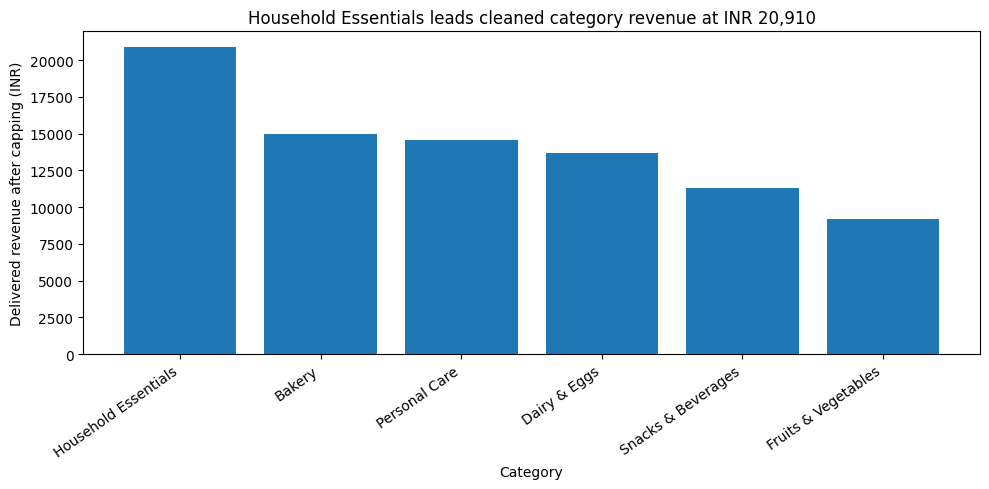

In [11]:
plt.figure(figsize=(10,5))
plt.bar(category_revenue['category'], category_revenue['total_revenue'])
plt.title('Household Essentials leads cleaned category revenue at INR 20,910')
plt.xlabel('Category')
plt.ylabel('Delivered revenue after capping (INR)')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

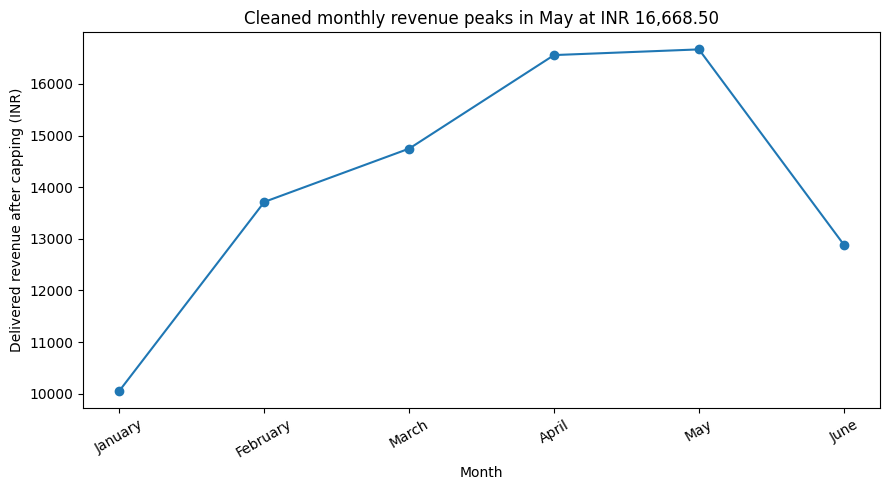

,month,month_name,total_revenue
0,1,January,10059.5
1,2,February,13715.0
2,3,March,14747.5
3,4,April,16558.5
4,5,May,16668.5
5,6,June,12888.0


In [12]:
monthly_revenue = (
    revenue_df.groupby(['month','month_name'], as_index=False)['amount_capped']
    .sum()
    .rename(columns={'amount_capped':'total_revenue'})
    .sort_values('month')
)

plt.figure(figsize=(9,5))
plt.plot(monthly_revenue['month_name'], monthly_revenue['total_revenue'], marker='o')
plt.title('Cleaned monthly revenue peaks in May at INR 16,668.50')
plt.xlabel('Month')
plt.ylabel('Delivered revenue after capping (INR)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

display(monthly_revenue)

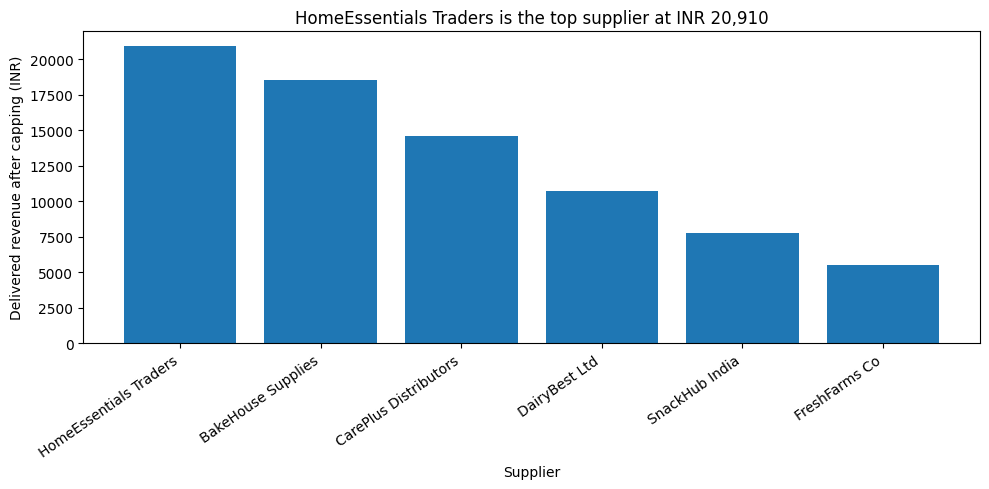

In [13]:
top_suppliers = supplier_revenue.head(6)
plt.figure(figsize=(10,5))
plt.bar(top_suppliers['supplier'], top_suppliers['total_revenue'])
plt.title('HomeEssentials Traders is the top supplier at INR 20,910')
plt.xlabel('Supplier')
plt.ylabel('Delivered revenue after capping (INR)')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()


## 9. Exactly three What / Why / Next-step observations

### Observation 1
**What:** Household Essentials is the highest-revenue category after cleaning and IQR capping, at **INR 20,910**, versus **INR 14,975** for the second-ranked Bakery category.  
**Why it matters:** The leading category contributes the strongest post-cleaning revenue signal and remains the same leader as the SQL diagnostic.  
**Next step:** Drill into Household Essentials product-level revenue and order counts to identify which items are driving the category lead and should be protected from stock-outs.

### Observation 2
**What:** Cleaned Delivered revenue rises from **INR 10,059.50 in January** to a peak of **INR 16,668.50 in May**, then falls to **INR 12,888 in June**.  
**Why it matters:** The June decline is large enough to warrant checking whether it reflects category mix, fewer Delivered orders, or lower-value orders rather than assuming steady growth.  
**Next step:** Compare May versus June by category and order count to locate the categories responsible for the decline.

### Observation 3
**What:** HomeEssentials Traders is the top supplier after cleaning at **INR 20,910**, while BakeHouse Supplies is second at **INR 18,550**.  
**Why it matters:** Supplier concentration aligns with the top-performing Household Essentials category and confirms the same leading supplier identified by Part 1.  
**Next step:** Review supplier-level product availability and service performance for HomeEssentials Traders, while benchmarking BakeHouse Supplies as the nearest revenue comparator.


## 10. Final audit values

In [14]:
print('Rows after duplicate removal:', len(df))
print('Missing revenue rows excluded from revenue sums:', df['amount_inr'].isna().sum())
print('Rows capped:', outlier_count)
print('Cleaned/capped Delivered revenue:', revenue_df['amount_capped'].sum())
print('Delivered rows with non-null revenue:', len(revenue_df))
print('Top category:', category_revenue.iloc[0].to_dict())
print('Top supplier:', supplier_revenue.iloc[0].to_dict())

Rows after duplicate removal: 500
Missing revenue rows excluded from revenue sums: 10
Rows capped: 16
Cleaned/capped Delivered revenue: 84637.0
Delivered rows with non-null revenue: 425
Top category: {'category': 'Household Essentials', 'total_revenue': 20910.0}
Top supplier: {'supplier': 'HomeEssentials Traders', 'total_revenue': 20910.0}
